In [ ]:
## IMPORTS
import numpy as np              # For numerical operations and array manipulations
import matplotlib.pyplot as plt # For plotting and visualization
import pandas as pd             # For data handling and CSV file reading
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.metrics import precision_score, recall_score, f1_score, silhouette_score  # For evaluation metrics
from sklearn.decomposition import PCA  # For dimensionality reduction (PCA for visualization)
import requests                 # For downloading images or data from URLs (used in Tasks 1 and 2)
from io import BytesIO          # For handling binary data streams (used with requests)
from PIL import Image           # For image processing (used in Tasks 1 and 2)
import cv2                      # For computer vision tasks
from sklearn.manifold import TSNE #Again useful for NL dimensionality reduction


## **Part 1:** Image Segmentation with Clustering

**Objective:** This task explores the application of unsupervised clustering techniques to partition an image into meaningful regions based on pixel similarities. By implementing algorithms like K-means and K-medoids, I investigated how to automatically segment visual data, which is crucial for tasks like object recognition and image editing, offering a foundation for understanding pattern recognition in computer vision.

In [ ]:


url = "https://media.wired.com/photos/5b7c67dff521ce3ac9ba45e9/16:9/w_2240,h_1260,c_limit/post10%5Bhttps-_goo.gl_maps_g65Rg5BDBsQ2%5D-(1).jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img = np.array(img)

img_resized = np.array(Image.fromarray(img).resize((100, 100)))
height, width, _ = img_resized.shape
pixels = img_resized.reshape(-1, 3).astype(float) / 255.0  # normalize

def rgb_to_ycbcr(rgb):
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 0.5 * b - 0.1687 * r - 0.3313 * g + 0.5
    cr = 0.5 * r - 0.4187 * g - 0.0813 * b + 0.5
    return np.column_stack((y, cb, cr))

pixels_ycbcr = rgb_to_ycbcr(pixels)

features = pixels_ycbcr

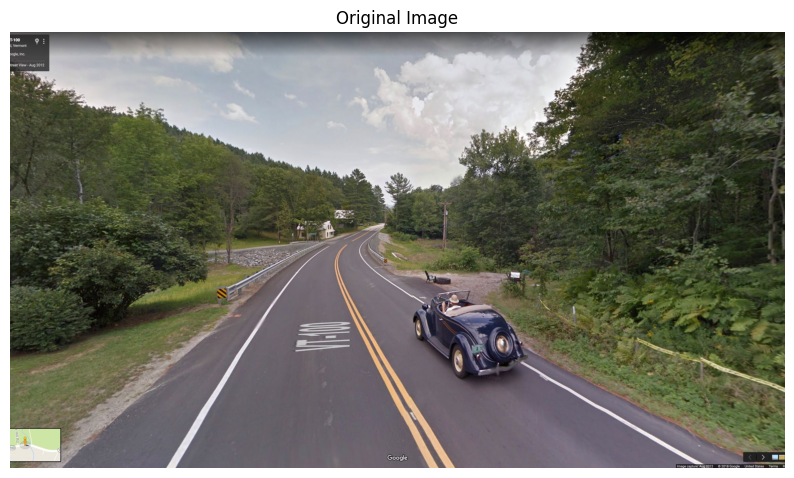

In [ ]:


plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

<span style="color: purple; font-size: 20px;">**Task 1.1:**</span>

In this task, I implementd clustering algorithms to group data points based on their features. Your goal is to create functions for initializing and performing two popular clustering techniques. Follow these steps to complete the task:

-  Implemented a smart **initialization method for K-means clustering** that selects initial centroids to improve convergence.
-  Developed the **K-means algorithm**, allowing for a custom initialization option to enhance clustering efficiency.
-  Created a **K-medoids algorithm**, which uses actual data points as cluster representatives instead of means, focusing on robustness to outliers.
-  Used NumPy for efficient vectorized operations to assign points to clusters and update centroids or medoids.



In [ ]:
def kmeanspp_init(X, k):
    n = X.shape[0]
    centroids = np.zeros((k, X.shape[1]))
    centroids[0] = X[np.random.randint(n)]
    distances = np.full(n, np.inf)

   
    for i in range(1,k):
        # Compute distance from point to the nearest selected centroid
        sq_distances_to_centroids = np.sum((X[:, np.newaxis, :] - centroids[np.newaxis, :i, :])**2, axis=2)
        sq_distance = np.min(sq_distances_to_centroids, axis=1)


        # Select next centroid with probability proportional to squared distance
        probs = sq_distance / np.sum(sq_distance)
        idx_next = np.random.choice (n, p=probs)
        centroids[i] = X[idx_next]

    return centroids

def kmeans(X, k, max_iter=100, init='random'):
    n, d = X.shape
    if init == 'kmeanspp':
        centroids = kmeanspp_init(X, k)
    else:
        centroids = X[np.random.choice(n, k, replace=False)]

    
    labels = np.zeros(n)
    for _ in range (max_iter):
        # Calculate the distance between the each centroid and each point
        distances = np.linalg.norm(X[:, np.newaxis]-centroids, axis=2)
        # Assign each point to the nearest centroid
        new_labels =np.argmin(distances, axis=1)
        # If no change in label, stop
        if np.all(labels == new_labels):
          break
        labels = new_labels

        # Update mean as the centroid in each cluster
        for i in range (k):
          if np.any(labels ==i):
            centroids[i] =X[labels == i].mean(axis=0)
    return labels, centroids

def kmedoids(X, k, max_iter=100):
    n, d = X.shape
    medoids_idx = np.random.choice(n, k, replace=False)
    medoids = X[medoids_idx]
    
    labels = np.zeros(n, dtype=int)

    for _ in range(max_iter):
        # Assign points to the nearest medoid
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        new_labels = np.argmin(distances, axis=1)

        # Update medoids
        new_medoids_idx = np.copy(medoids_idx)
        for i in range(k):
            clusters_indices = np.where(new_labels == i)[0]
            if len(clusters_indices) == 0:
                continue

            cluster_points = X[clusters_indices]
            # Estimate total distance for each point in the cluster
            dist_sum = np.sum(np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, axis=2), axis=1)
            # Select the point with the shortest total distance
            new_medoid_cluster_index = np.argmin(dist_sum)
            new_medoids_idx[i] = clusters_indices[new_medoid_cluster_index]

        # In case the medoids have not changed then stop
        if np.all(new_medoids_idx == medoids_idx):
            labels = new_labels
            break

        medoids_idx = new_medoids_idx
        medoids = X[medoids_idx]
        labels = new_labels

    return labels, medoids




In [ ]:

def agglomerative(X, k):
    n = X.shape[0]
    # since n is large, lets sample a subset
    if n > 1000:
        sample_idx = np.random.choice(n, 1000, replace=False)
        X_sample = X[sample_idx]
    else:
        X_sample = X
        sample_idx = np.arange(n)

    m = X_sample.shape[0]
    clusters = list(range(m))
    dist_matrix = np.linalg.norm(X_sample[:, np.newaxis] - X_sample, axis=2)

    while len(set(clusters)) > k:

        # find closest pairs
        min_dist = np.inf
        pair = (-1, -1)
        for i in range(m):
            for j in range(i+1, m):
                if clusters[i] != clusters[j] and dist_matrix[i, j] < min_dist:
                    min_dist = dist_matrix[i, j]
                    pair = (clusters[i], clusters[j])

        # merge
        for i in range(m):
            if clusters[i] == pair[1]:
                clusters[i] = pair[0]

    # map to labels
    unique_clusters = list(set(clusters))
    label_map = {c: i for i, c in enumerate(unique_clusters)}
    sample_labels = np.array([label_map[c] for c in clusters])

    # assign all points to nearest sample cluster centers (approximate)
    centers = np.array([X_sample[sample_labels == i].mean(axis=0) for i in range(k)])
    distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)

    return labels

In [ ]:

val_k = 5

labels_kmeans, centroids_kmeans = kmeans(features, k=val_k, init='kmeanspp')
labels_kmedoids, medoids = kmedoids(features, k=val_k)
labels_agg = agglomerative(features, k=val_k)

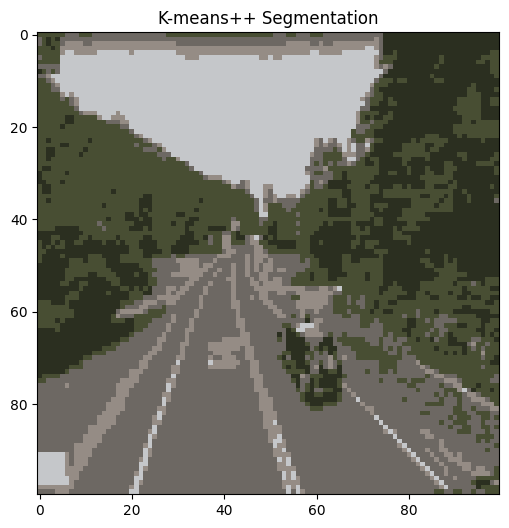

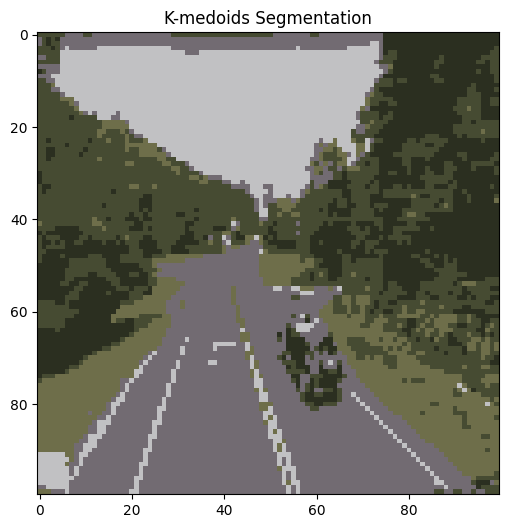

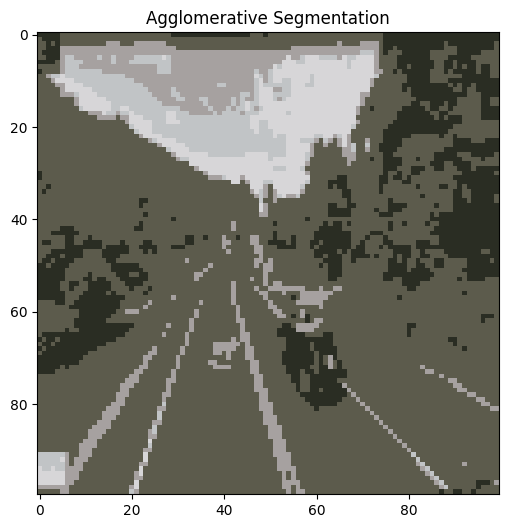

In [ ]:
def visualize_segmentation(img, labels, k, title):
    segmented = np.zeros_like(img)
    for i in range(k):
        mask = (labels == i).reshape(img.shape[:2])
        color = img[mask].mean(axis=0)
        segmented[mask] = color.astype(int)
    plt.figure(figsize=(8, 6))
    plt.imshow(segmented)
    plt.title(title)
    plt.show()

visualize_segmentation(img_resized, labels_kmeans, val_k, 'K-means++ Segmentation')
visualize_segmentation(img_resized, labels_kmedoids, val_k, 'K-medoids Segmentation')
visualize_segmentation(img_resized, labels_agg, val_k, 'Agglomerative Segmentation')

<span style="color: purple; font-size: 20px;">**Task 1.2:**</span>

In this task, I implemented a function to evaluate the quality of clustering by calculating the **Within-Cluster Sum of Squares (WCSS)**.  
This metric measures the compactness of clusters. Follow these steps to complete the task:

- Defined a function that takes data points (`X`), cluster labels, and cluster centers (centroids or medoids) as inputs.  
- Computed WCSS using the formula:

$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - c_i \|^2
$$

where \\( k \\) is the number of clusters, \\( C_i \\) is the set of points in cluster \\( i \\), \\( x \\) is a point, and \\( c_i \\) is the cluster center.  

- Used NumPy to calculate squared Euclidean distances between points and their assigned centers.  
- Handled edge cases, such as empty clusters, by skipping them in the summation.  
- Returned the total WCSS score as a float.  


In [116]:
def calculate_wcss(X, labels, centroids_or_medoids):
    """
    Calculate Within-Cluster Sum of Squares manually.

    Parameters:
    - X: numpy array of shape (n_samples, n_features) containing the data points
    - labels: numpy array of shape (n_samples,) containing cluster labels
    - centroids_or_medoids: numpy array of shape (n_clusters, n_features) containing cluster centers

    Returns:
    - wcss: float, the total WCSS score
    """
    n_clusters = len(np.unique(labels))
    wcss = 0.0

    # YOUR CODE HERE
    for i in range (n_clusters):
        # Slect points in the clusters
        cluster_points =X[labels ==i]
        if len (cluster_points) ==0: # Skip in case cluster is empty
            continue
        # Get center for the cluster
        center = centroids_or_medoids[i]
        # Calculate squared distances between the center and the points
        distances_squared = np.sum((cluster_points - center)**2, axis=1)
        # Add total WCSS
        wcss += np.sum(distances_squared)

    return wcss

K-means++ Metrics:
  Silhouette Score: 0.4997
  Within-Cluster Sum of Squares (WCSS): 27.0686

K-medoids Metrics:
  Silhouette Score: 0.4859
  Within-Cluster Sum of Squares (WCSS): 33.7855

Agglomerative Metrics:
  Silhouette Score: 0.3254
  Within-Cluster Sum of Squares (WCSS): 67.7954



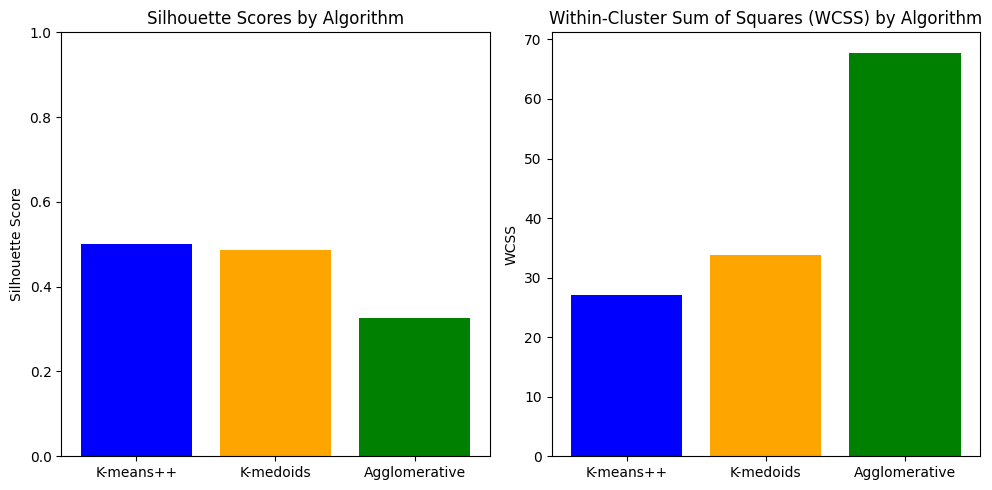

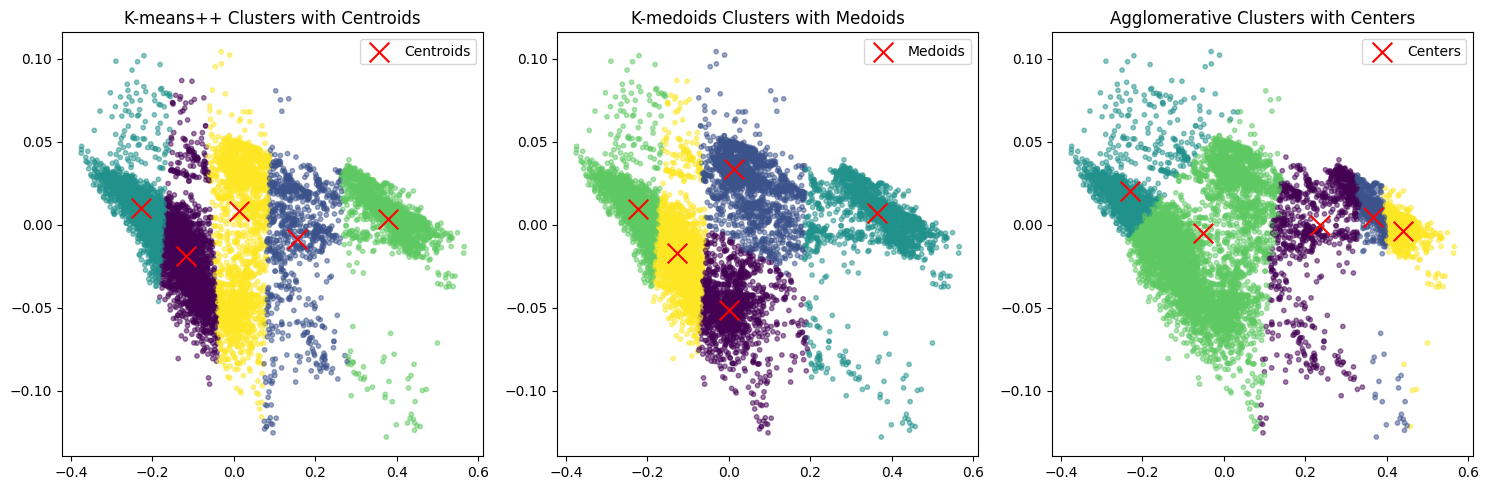

In [ ]:

def calculate_metrics(X, labels, centroids_or_medoids=None, algorithm_name=""):
    if len(set(labels)) < 2:
        sil_score = 0
    else:
        sil_score = silhouette_score(X, labels)

    if centroids_or_medoids is not None and len(np.unique(labels)) > 0:
        wcss = calculate_wcss(X, labels, centroids_or_medoids)
    else:
        wcss = 0.0

    print(f"{algorithm_name} Metrics:")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Within-Cluster Sum of Squares (WCSS): {wcss:.4f}\n")
    return sil_score, wcss

sil_kmeans, wcss_kmeans = calculate_metrics(features, labels_kmeans, centroids_kmeans, "K-means++")
sil_kmedoids, wcss_kmedoids = calculate_metrics(features, labels_kmedoids, medoids, "K-medoids")
sil_agg, wcss_agg = calculate_metrics(features, labels_agg, np.array([features[labels_agg == i].mean(axis=0) for i in range(val_k) if np.any(labels_agg == i)]), "Agglomerative")

algorithms = ['K-means++', 'K-medoids', 'Agglomerative']
sil_scores = [sil_kmeans, sil_kmedoids, sil_agg]
wcss_values = [wcss_kmeans, wcss_kmedoids, wcss_agg]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(algorithms, sil_scores, color=['blue', 'orange', 'green'])
plt.title('Silhouette Scores by Algorithm')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(algorithms, wcss_values, color=['blue', 'orange', 'green'])
plt.title('Within-Cluster Sum of Squares (WCSS) by Algorithm')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

plt.subplot(1, 3, 1)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.5, s=10)
plt.scatter(pca.transform(centroids_kmeans)[:, 0], pca.transform(centroids_kmeans)[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title('K-means++ Clusters with Centroids')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_kmedoids, cmap='viridis', alpha=0.5, s=10)
plt.scatter(pca.transform(medoids)[:, 0], pca.transform(medoids)[:, 1], c='red', marker='x', s=200, label='Medoids')
plt.title('K-medoids Clusters with Medoids')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_agg, cmap='viridis', alpha=0.5, s=10)
centroids_agg = np.array([features[labels_agg == i].mean(axis=0) for i in range(val_k) if np.any(labels_agg == i)])
plt.scatter(pca.transform(centroids_agg)[:, 0], pca.transform(centroids_agg)[:, 1], c='red', marker='x', s=200, label='Centers')
plt.title('Agglomerative Clusters with Centers')
plt.legend()

plt.tight_layout()
plt.show()

---
## Analysis of Results

k=2, MSE=105.1491
k=3, MSE=83.6822
k=4, MSE=80.8017
k=5, MSE=72.4625


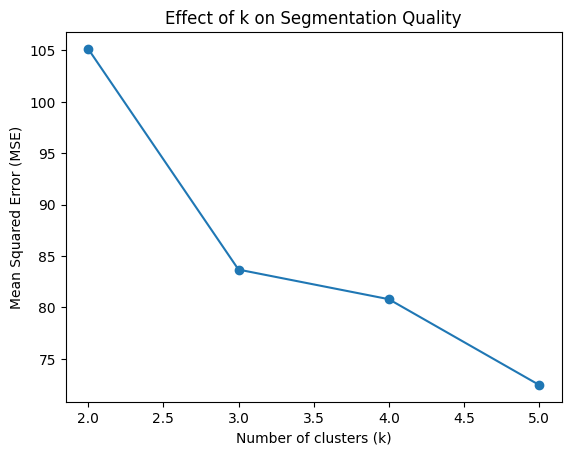

In [ ]:


def calculate_mse(original, segmented):
    return np.mean((original - segmented) ** 2)
    k_values = [3, 5, 8, 10]
mse_values = []

for k in k_values:
    labels, centroids = kmeans(features, k, init='kmeanspp')

    # Recreate segmented image
    segmented = np.zeros_like(img_resized)
    for i in range(k):
        mask = (labels == i).reshape(img_resized.shape[:2])
        color = img_resized[mask].mean(axis=0)
        segmented[mask] = color.astype(int)

    mse = calculate_mse(img_resized, segmented)
    mse_values.append(mse)
    print(f"k={k}, MSE={mse:.4f}")

plt.plot(k_values, mse_values, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Effect of k on Segmentation Quality")
plt.show()



## **Part 2:** Anomaly Detection in Credit Card Transactions

**Objective:** This task delves into detecting unusual patterns in financial data using clustering methods, focusing on identifying fraudulent credit card transactions. By exploring algorithms like K-means++, K-medoids, and DBSCAN, you will address a real-world challenge in cybersecurity and fraud prevention, highlighting the importance of anomaly detection in protecting economic systems.

**Task Preparation:** Before starting the analysis, please download the required dataset from KAGGLE to work with the credit card fraud detection tasks. Follow these steps:

- Visit the following link: [Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
- Download the `creditcard.csv` file directly, or extract from zipped folder after downloading the dataset.
- Save the file in your working directory to ensure the code can access it, or add to runtime if working with Colab.



In [ ]:


df = pd.read_csv('creditcard.csv')

# features: drop Time (not useful), use V1-V28 and Amount
X = df.drop(['Time', 'Class'], axis=1).values
y = df['Class'].values  # y is our target

# preprocessing: standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# subsampling
fraud_idx = np.where(y == 1)[0]
normal_idx = np.random.choice(np.where(y == 0)[0], 5000, replace=False)
sample_idx = np.concatenate((normal_idx, fraud_idx))
X_sample = X_scaled[sample_idx]
y_sample = y[sample_idx]

print(f'Sampled data: {X_sample.shape[0]} points, {np.sum(y_sample)} fraud')

Sampled data: 5492 points, 492 fraud


<span style="color: purple; font-size: 20px;">**Task 2.1:**</span> In this task, an exploratory data analysis (EDA) of the Credit Card Fraud dataset is conducted. The dataset contains information about credit card transactions, including the amount of the transaction, the date of the transaction, and the name of the cardholder. The EDA is performed using the pandas library in Python.

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraudulent Transactions: 0.1727%

Summary Statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848

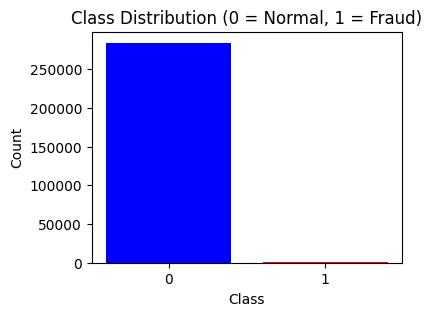


Numerical Correlation Matrix (rounded to 2 decimals):
        Time    V1    V2    V3    V4    V5    V6    V7    V8    V9  ...   V21  \
Time    1.00  0.12 -0.01 -0.42 -0.11  0.17 -0.06  0.08 -0.04 -0.01  ...  0.04   
V1      0.12  1.00  0.00 -0.00 -0.00  0.00 -0.00 -0.00 -0.00 -0.00  ... -0.00   
V2     -0.01  0.00  1.00  0.00 -0.00  0.00  0.00  0.00 -0.00  0.00  ... -0.00   
V3     -0.42 -0.00  0.00  1.00  0.00 -0.00  0.00  0.00 -0.00  0.00  ...  0.00   
V4     -0.11 -0.00 -0.00  0.00  1.00 -0.00 -0.00 -0.00  0.00  0.00  ... -0.00   
V5      0.17  0.00  0.00 -0.00 -0.00  1.00  0.00  0.00  0.00  0.00  ... -0.00   
V6     -0.06 -0.00  0.00  0.00 -0.00  0.00  1.00  0.00 -0.00  0.00  ...  0.00   
V7      0.08 -0.00  0.00  0.00 -0.00  0.00  0.00  1.00  0.00  0.00  ... -0.00   
V8     -0.04 -0.00 -0.00 -0.00  0.00  0.00 -0.00  0.00  1.00  0.00  ...  0.00   
V9     -0.01 -0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  ...  0.00   
V10     0.03  0.00 -0.00  0.00  0.00 -0.00  0.00 -0.00

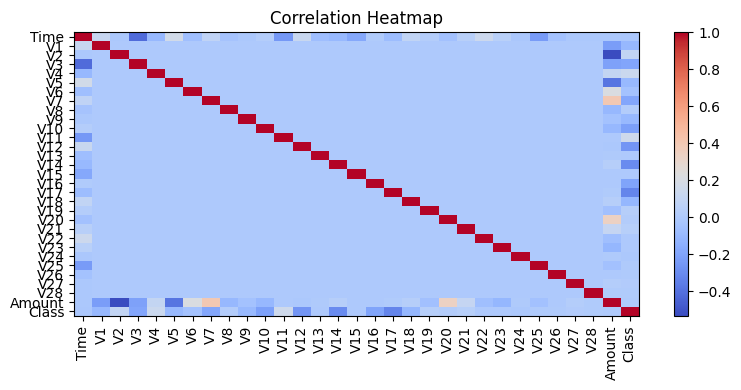

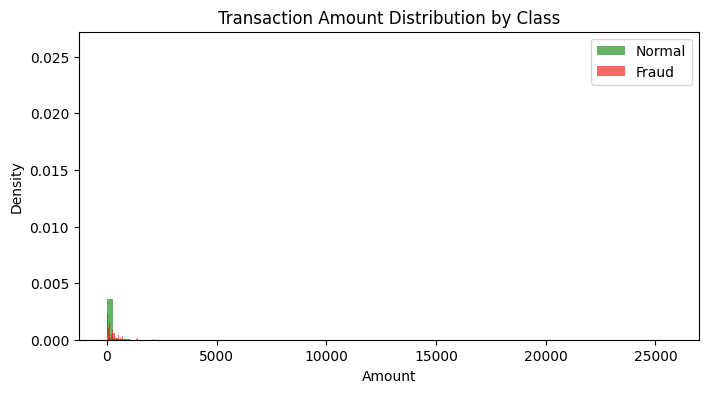

In [ ]:

# Summary of the dataset
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nPercentage of Fraudulent Transactions: {:.4f}%".format(df['Class'].mean() * 100))

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Plot class imbalance
plt.figure(figsize=(4, 3))
class_counts = df['Class'].value_counts()
plt.bar(class_counts.index.astype(str), class_counts.values, color=['blue', 'red'])
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Correlation Table and Correlation heatmap

corr_matrix = df.corr()
print("\nNumerical Correlation Matrix (rounded to 2 decimals):")
print(corr_matrix.round(2))
plt.figure(figsize=(8, 4))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Distribution for normal vs fraud -  Amount
plt.figure(figsize=(8, 4))
plt.hist(df[df['Class'] == 0]['Amount'], bins=100, alpha=0.6, label='Normal', color='green', density=True)
plt.hist(df[df['Class'] == 1]['Amount'], bins=100, alpha=0.6, label='Fraud', color='red', density=True)
plt.legend()
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()





Add the relevant functions in the cell below, you may use your implementations from **Part 1**

In [ ]:
# From Task 1 (copy the functions from the previous part)
def kmeanspp_init(X, k):
    n = X.shape[0]
    centroids = np.zeros((k, X.shape[1]))
    centroids[0] = X[np.random.randint(n)]
    distances = np.full(n, np.inf)
    for i in range (1,k):
      # Estimate the squared distance from each point to nearest centroids
        # Compute squared distances from each point to the nearest centroid selected so far
        sq_distances_to_centroids = np.sum((X[:, np.newaxis, :] - centroids[np.newaxis, :i, :]) ** 2, axis=2)
        sq_distance = np.min(sq_distances_to_centroids, axis=1)

        # Probability proportional to squared distance
        probs = sq_distance / np.sum(sq_distance)

        # Choose the next centroid index based on these probabilities
        idx_next = np.random.choice(n, p=probs)
        centroids[i] = X[idx_next]

    return centroids

def kmeans(X, k, max_iter=100, init='kmeanspp'):
    n, d = X.shape
    if init == 'kmeanspp':
        centroids = kmeanspp_init(X, k)
    else:
        centroids = X[np.random.choice(n, k, replace=False)]

    #YOUR CODE HERE
    labels = np.zeros(n, dtype=int) #Intialize labels
    for _ in range(max_iter):
        # Compute distances from points to centroids
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

        # Assign each point to closest centroid
        new_labels = np.argmin(distances, axis=1)

        # Check for convergence (no label change)
        if np.all(labels == new_labels):
            break

        labels = new_labels

        # Update centroids as mean of assigned points
        for i in range(k):
            if np.any(labels == i):
                centroids[i] = X[labels == i].mean(axis=0)
    return labels, centroids

def kmedoids(X, k, max_iter=100):
    n, d = X.shape
    medoids_idx = np.random.choice(n, k, replace=False)
    medoids = X[medoids_idx]

    
    for _ in range(max_iter):
        # Assign points to nearest medoid
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        new_labels = np.argmin(distances, axis=1)

        # Update medoids
        new_medoids_idx = np.copy(medoids_idx)
        for i in range(k):
            cluster_indices = np.where(new_labels == i)[0]
            if len(cluster_indices) == 0:
                continue

            cluster_points = X[cluster_indices]
            # Sum of distances from each point to all other points in cluster
            dist_sum = np.sum(np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, axis=2), axis=1)
            # Select the point minimizing total distance
            new_medoid_idx = np.argmin(dist_sum)
            new_medoids_idx[i] = cluster_indices[new_medoid_idx]

        # Stop if medoids don't change
        if np.all(new_medoids_idx == medoids_idx):
            labels = new_labels
            break

        medoids_idx = new_medoids_idx
        medoids = X[medoids_idx]
        labels = new_labels
    return labels, medoids


<span style="color: purple; font-size: 20px;">**Task 2.2:**</span> In this task, implement a density-based clustering algorithm to identify clusters and noise in a dataset. Your goal is to develop a function that groups points based on their density. Follow these steps to complete the task:

- Implement the DBSCAN algorithm, which relies on the concept of density-reachable points within a specified radius (eps).  
- Define a `region_query` function to calculate the Euclidean distance \\( \| x_i - x_j \| \\) between a point and all others, returning points within the eps radius.  
- Create an `expand_cluster` function to grow clusters by checking if a point has at least `min_samples` neighbors, using the density-connectivity rule \\( \text{number of points} \geq \min_samples \\).  
- Assign labels where -1 indicates noise, and increment cluster IDs for core points with sufficient neighbors.  



In [44]:
def dbscan(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -1)  # -1: noise
    cluster_id = 0

    def region_query(point_idx):
        # YOUR CODE HERE
        # Calculate the distances from point_idx to all points
        distances = np.linalg.norm(X - X[point_idx], axis = 1)
        # Return the indicies of points in radius
        return np.where(distances <= eps ) [0]


    def expand_cluster(point_idx, neighbors):
        #YOUR CODE HERE
        nonlocal cluster_id
        labels[point_idx] = cluster_id
        i = 0
        while i < len (neighbors):
          neighbor_idx = neighbors[i]
          if labels[neighbor_idx] == -1: # Previously noise now part of the cluster
              labels [neighbor_idx] = cluster_id
              # Check if this neighbor is also a core point
              neighbor_neighbors = region_query(neighbor_idx)
              if len(neighbor_neighbors) >= min_samples:
                    # Add new neighbors to explore
                    neighbors_to_add = neighbor_neighbors[labels[neighbor_neighbors] < 0] # only add unclassified/noise
                    neighbors = np.unique(np.append(neighbors, neighbors_to_add))

          i += 1
    for point_idx in range(n):
      if labels[point_idx] != -1:
          continue

      neighbors = region_query(point_idx)
      if len(neighbors) < min_samples: # mark as noise (already -1)
          continue

      # Expand cluster, core point found
      expand_cluster(point_idx, neighbors)
      cluster_id += 1

    return labels



In [ ]:



# --------------K-means++ applied---------------
labels_kmeans, _ = kmeans(X_sample, k=3)

cluster_sizes = np.bincount(labels_kmeans) # map anomaly cluster: we assume here that the smaller cluster is fraud (anomaly)
anomaly_cluster_kmeans = np.argmin(cluster_sizes)
pred_kmeans = (labels_kmeans == anomaly_cluster_kmeans).astype(int)

# -----------K-medoids applied--------------
labels_kmedoids, _ = kmedoids(X_sample, k=3)
cluster_sizes = np.bincount(labels_kmedoids)
anomaly_cluster_kmedoids = np.argmin(cluster_sizes)
pred_kmedoids = (labels_kmedoids == anomaly_cluster_kmedoids).astype(int)

# -----------DBSCAN applied(tune eps and min_samples for the dataset)---------------

labels_dbscan = dbscan(X_sample, eps=4.0, min_samples=10)  # adjust based on data scale
# noise (-1) as anomalies (fraud)
pred_dbscan = (labels_dbscan == -1).astype(int)

Visualize Clusters (PCA + t-SNE for 2D Projection)

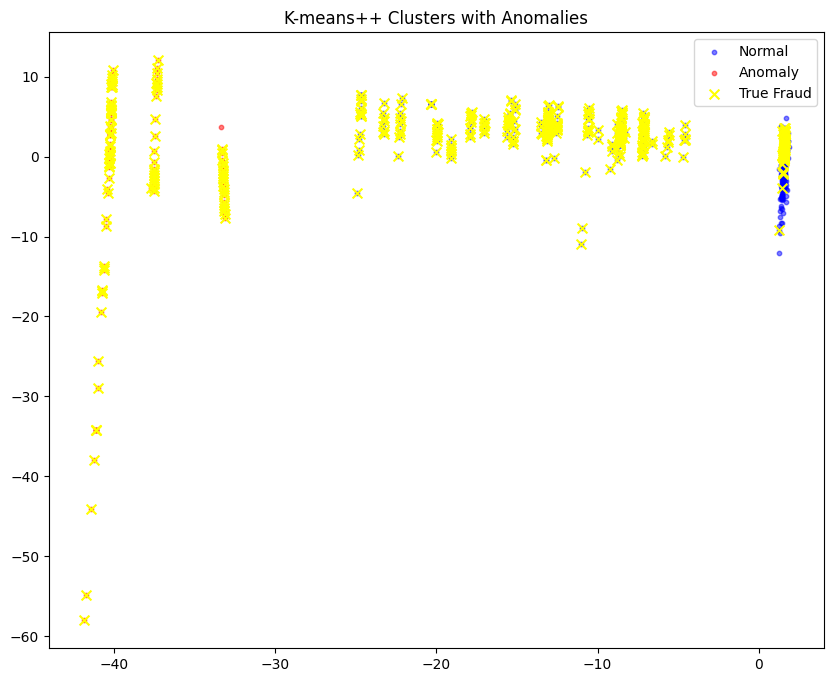

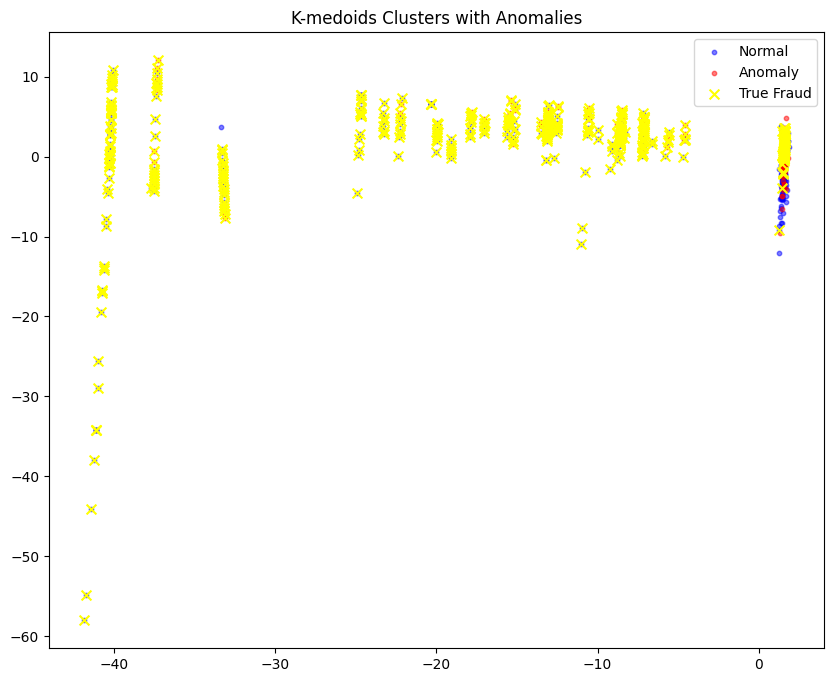

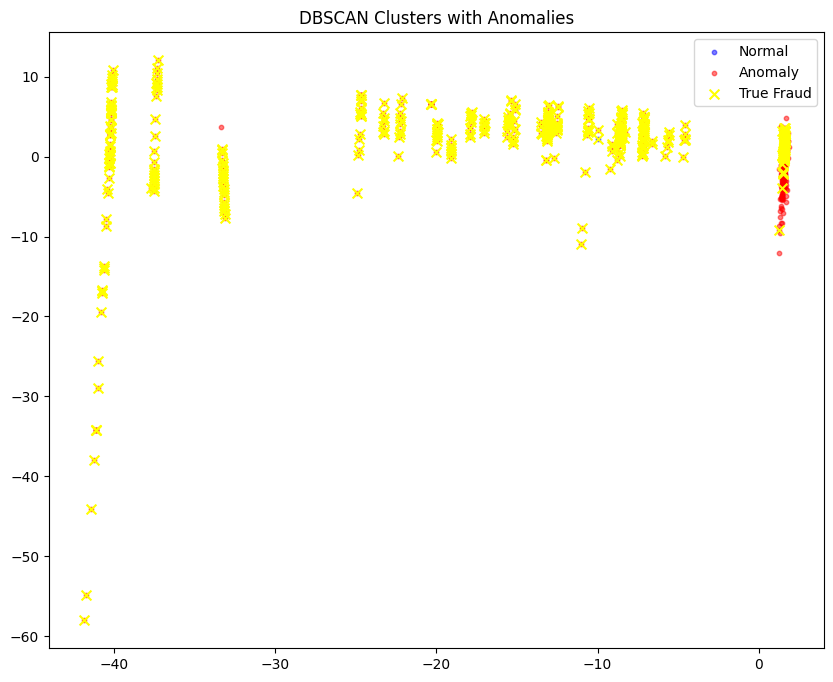

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

def plot_clusters_enhanced(X_pca, labels, y_true, title):
    plt.figure(figsize=(10, 8))

    if -1 in labels:
        anomaly_mask = (labels == -1)
    else:
        anomaly_mask = (labels == np.argmin(np.bincount(labels[labels >= 0])))
    plt.scatter(X_pca[~anomaly_mask, 0], X_pca[~anomaly_mask, 1], c='blue', label='Normal', alpha=0.5, s=10)
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], c='red', marker = 'o',label='Anomaly', alpha=0.5, s=10)

    plt.scatter(X_pca[y_true == 1, 0], X_pca[y_true == 1, 1], c='yellow',marker = 'x', label='True Fraud', s=50)
    plt.title(title)
    plt.legend()
    plt.show()

plot_clusters_enhanced(X_pca, labels_kmeans, y_sample, 'K-means++ Clusters with Anomalies')
plot_clusters_enhanced(X_pca, labels_kmedoids, y_sample, 'K-medoids Clusters with Anomalies')
plot_clusters_enhanced(X_pca, labels_dbscan, y_sample, 'DBSCAN Clusters with Anomalies')

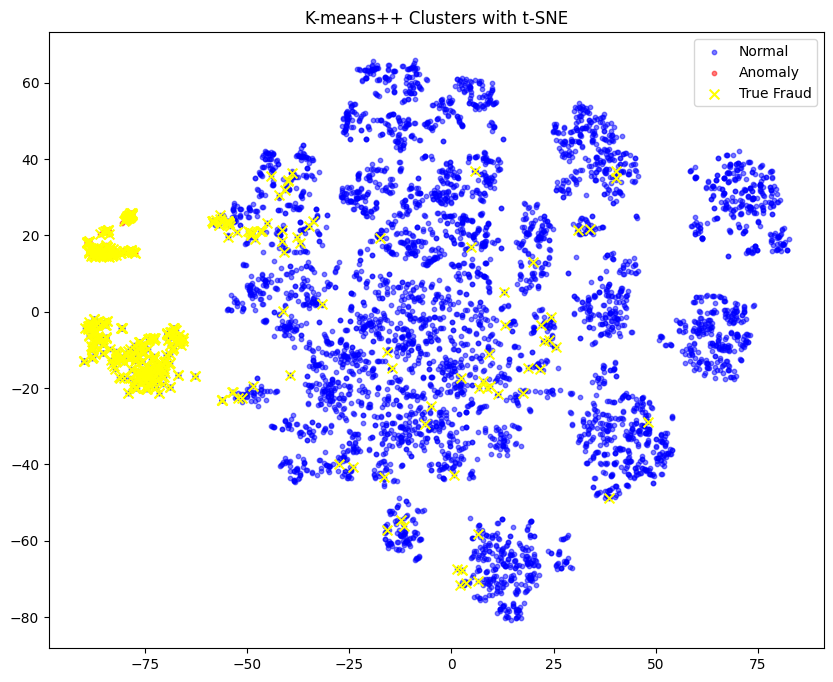

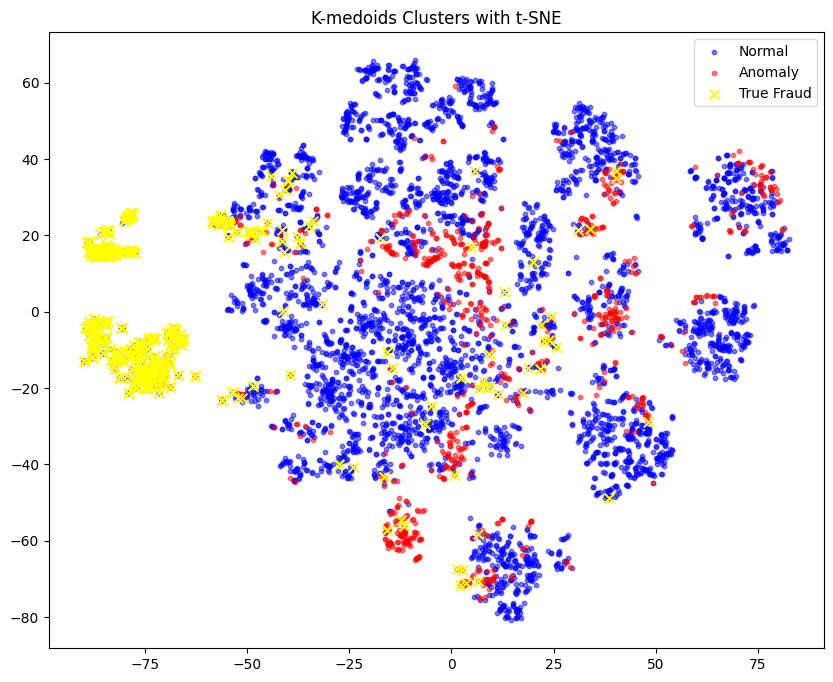

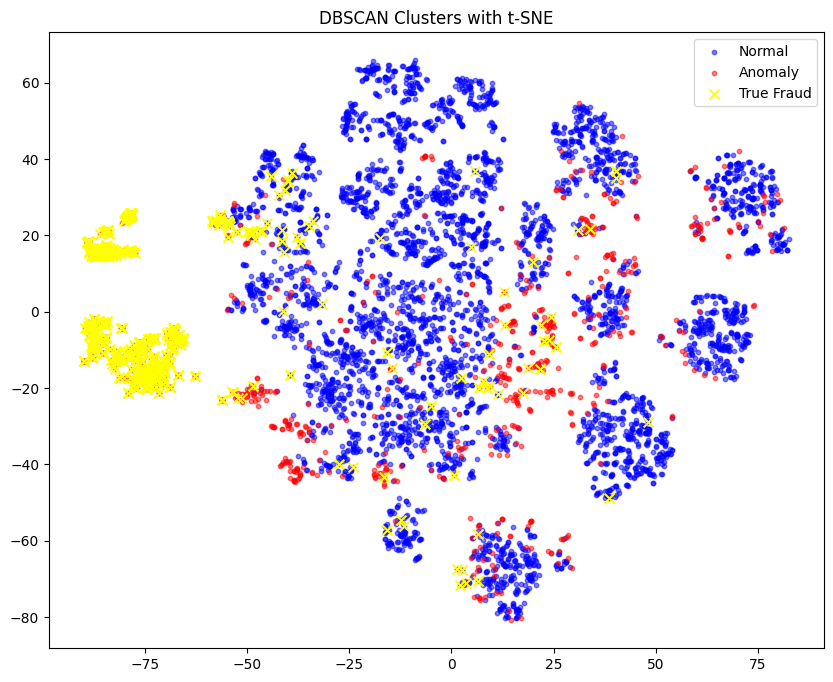

In [ ]:


tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

def plot_clusters_tsne(X_tsne, labels, y_true, title):
    plt.figure(figsize=(10, 8))

    if np.any(labels < 0):
        anomaly_mask = (labels == -1)
    else:
        anomaly_mask = (labels == np.argmin(np.bincount(labels + (labels < 0).astype(int))))

    plt.scatter(X_tsne[~anomaly_mask, 0], X_tsne[~anomaly_mask, 1], c='blue', label='Normal', alpha=0.5, s=10)

    plt.scatter(X_tsne[anomaly_mask, 0], X_tsne[anomaly_mask, 1], c='red', marker = 'o', label='Anomaly', alpha=0.5, s=10)

    plt.scatter(X_tsne[y_true == 1, 0], X_tsne[y_true == 1, 1], c='yellow', marker = 'x', label='True Fraud', s=50)
    plt.title(title)
    plt.legend()
    plt.show()


plot_clusters_tsne(X_tsne, labels_kmeans, y_sample, 'K-means++ Clusters with t-SNE')
plot_clusters_tsne(X_tsne, labels_kmedoids, y_sample, 'K-medoids Clusters with t-SNE')
plot_clusters_tsne(X_tsne, labels_dbscan, y_sample, 'DBSCAN Clusters with t-SNE')

In [ ]:

def evaluate(pred, y_true, algo_name):
    sil = silhouette_score(X_sample, pred) if len(set(pred)) > 1 else 0
    prec = precision_score(y_true, pred)
    rec = recall_score(y_true, pred)
    f1 = f1_score(y_true, pred)
    print(f'{algo_name}:')
    print(f'  Silhouette Score: {sil:.4f}')
    print(f'  Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}\n')
    return sil, prec, rec, f1

metrics = {}
metrics['K-means++'] = evaluate(pred_kmeans, y_sample, 'K-means++')
metrics['K-medoids'] = evaluate(pred_kmedoids, y_sample, 'K-medoids')
metrics['DBSCAN'] = evaluate(pred_dbscan, y_sample, 'DBSCAN')

print('Note:')
print('- Silhouette: Higher is better for clustering cohesion/separation.')
print('- Precision/Recall/F1: Higher is better for anomaly (fraud) detection.')

K-means++:
  Silhouette Score: 0.8063
  Precision: 0.9907, Recall: 0.2175, F1: 0.3567

K-medoids:
  Silhouette Score: 0.0784
  Precision: 0.1511, Recall: 0.2764, F1: 0.1954

DBSCAN:
  Silhouette Score: 0.4535
  Precision: 0.4149, Recall: 0.8476, F1: 0.5571

Note:
- Silhouette: Higher is better for clustering cohesion/separation.
- Precision/Recall/F1: Higher is better for anomaly (fraud) detection.


k = 2 | Precision: 0.9962, Recall: 0.5285, F1: 0.6906
k = 3 | Precision: 0.9907, Recall: 0.2175, F1: 0.3567
k = 4 | Precision: 0.9907, Recall: 0.2175, F1: 0.3567
k = 5 | Precision: 0.0658, Recall: 0.0102, F1: 0.0176


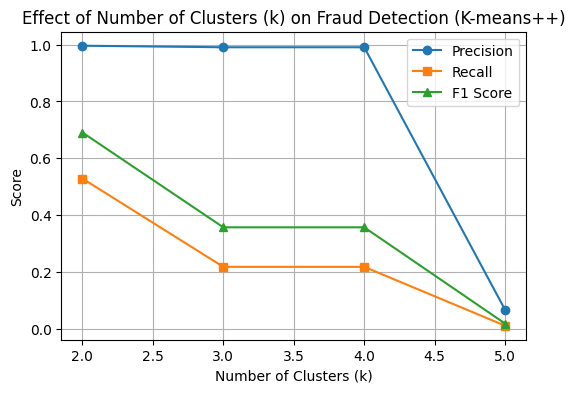

In [ ]:

#  Effect of k (number of clusters) on fraud detection with K-means++

k_values = [2, 3, 4, 5]
results = []

for k in k_values:
    labels_kmeans, _ = kmeans(X_sample, k=k)
    cluster_sizes = np.bincount(labels_kmeans)
    anomaly_cluster = np.argmin(cluster_sizes)
    pred_kmeans = (labels_kmeans == anomaly_cluster).astype(int)

    prec = precision_score(y_sample, pred_kmeans)
    rec = recall_score(y_sample, pred_kmeans)
    f1 = f1_score(y_sample, pred_kmeans)

    results.append((k, prec, rec, f1))
    print(f"k = {k} | Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

# Plot the metrics
results = np.array(results)
plt.figure(figsize=(6,4))
plt.plot(results[:,0], results[:,1], 'o-', label='Precision')
plt.plot(results[:,0], results[:,2], 's-', label='Recall')
plt.plot(results[:,0], results[:,3], '^-', label='F1 Score')
plt.title("Effect of Number of Clusters (k) on Fraud Detection (K-means++)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:


eps_values = [2.0, 3.0, 4.0]
min_samples_values = [5, 10, 15]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        labels_dbscan = dbscan(X_sample, eps=eps, min_samples=min_s)
        pred_dbscan = (labels_dbscan == -1).astype(int)

        # Evaluate
        sil = silhouette_score(X_sample, pred_dbscan) if len(set(pred_dbscan)) > 1 else 0
        prec = precision_score(y_sample, pred_dbscan)
        rec = recall_score(y_sample, pred_dbscan)
        f1 = f1_score(y_sample, pred_dbscan)

        results.append((eps, min_s, sil, prec, rec, f1))

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['eps', 'min_samples', 'Silhouette', 'Precision', 'Recall', 'F1'])
print(results_df.round(4))


   eps  min_samples  Silhouette  Precision  Recall      F1
0  2.0            5     -0.0275     0.1255  0.9065  0.2204
1  2.0           10     -0.1149     0.1192  0.9919  0.2129
2  2.0           15     -0.1597     0.1104  0.9939  0.1988
3  3.0            5      0.2232     0.2327  0.8211  0.3627
4  3.0           10      0.1984     0.2221  0.9248  0.3581
5  3.0           15      0.1651     0.2072  0.9431  0.3398
6  4.0            5      0.4407     0.3974  0.6728  0.4996
7  4.0           10      0.4535     0.4149  0.8476  0.5571
8  4.0           15      0.4392     0.4117  0.8902  0.5630


---

## **Part 3:** Skin Detection via YCbCr + GMM
**Objective:** This task investigates skin detection in images using the Gaussian Mixture Model (GMM) in the YCbCr color space, exploring how to model complex skin tone distributions for applications like face detection. By implementing this from scratch, you will uncover the power of probabilistic modeling in image processing, essential for tasks in biometrics and human-computer interaction.

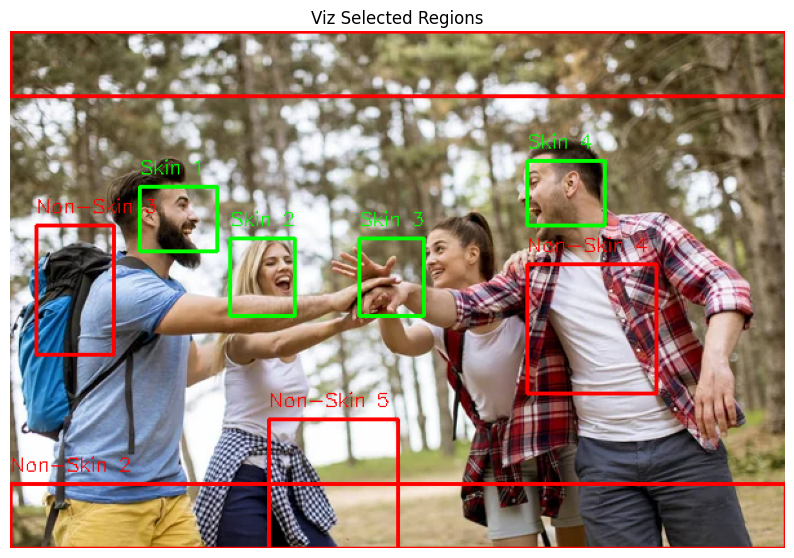

In [ ]:



url = 'https://st4.depositphotos.com/1022135/27218/i/450/depositphotos_272186204-stock-photo-group-young-people-hiking-mountain.jpg'

response = requests.get(url)
img_skin = Image.open(BytesIO(response.content))
img_skin = np.array(img_skin)

def rgb_to_ycbcr(rgb):
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 0.5 * b - 0.1687 * r - 0.3313 * g + 0.5
    cr = 0.5 * r - 0.4187 * g - 0.0813 * b + 0.5
    return np.column_stack((y, cb, cr))

pixels_skin = img_skin.reshape(-1, 3).astype(float) / 255.0
ycbcr_skin = rgb_to_ycbcr(pixels_skin)

# Get dimensions
h, w = img_skin.shape[:2]

skin_patches = [
    (120, 170, 100, 160),   # (start_row, end_row, start_col, end_col)
    (160, 220, 170, 220),
    (160, 220, 270, 320),
    (100, 150, 400, 460)
]
skin_indices = []
for sr, er, sc, ec in skin_patches:
    for row in range(sr, er):
        for col in range(sc, ec):
            skin_indices.append(row * w + col)
skin_region = ycbcr_skin[skin_indices]


non_skin_patches = [
    (0, 50, 0, w),         # Top
    (h-50, h, 0, w),       # Bottom
    (150, 250, 20, 80),   # Backpack
    (180, 280, 400, 500),    # Right trees
    (300, 400, 200, 300)   # Ground
]
non_skin_indices = []
for sr, er, sc, ec in non_skin_patches:
    for row in range(sr, er):
        for col in range(sc, ec):
            non_skin_indices.append(row * w + col)
non_skin_region = ycbcr_skin[non_skin_indices]

# Use CbCr channels
skin_cbcr = skin_region[:, 1:]
non_skin_cbcr = non_skin_region[:, 1:]
test_cbcr = ycbcr_skin[:, 1:]

img_with_regions = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)

for i, (sr, er, sc, ec) in enumerate(skin_patches):
    cv2.rectangle(img_with_regions, (sc, sr), (ec, er), (0, 255, 0), 2)  # green box
    cv2.putText(img_with_regions, f'Skin {i+1}', (sc, sr - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

for i, (sr, er, sc, ec) in enumerate(non_skin_patches):
    cv2.rectangle(img_with_regions, (sc, sr), (ec, er), (0, 0, 255), 2)  # red box
    cv2.putText(img_with_regions, f'Non-Skin {i+1}', (sc, sr - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_regions, cv2.COLOR_BGR2RGB))
plt.title('Viz Selected Regions')
plt.axis('off')
plt.show()

<span style="color: purple; font-size: 20px;">**Task 3.1:**</span>  
In this task, implement a Gaussian Mixture Model (GMM) using the Expectation-Maximization (EM) algorithm to model complex data distributions. Your goal is to develop functions that estimate the parameters of multiple Gaussian components. Follow these steps to complete the task:

- Implement the `gaussian_pdf` function to compute the probability density function of a Gaussian distribution, using the formula:  
  - \\( P(x) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right) \\)  
  - Where \\( d \\) is the dimensionality, \\( \mu \\) is the mean, \\( \Sigma \\) is the covariance matrix, and use NumPy for matrix operations (e.g., inverse, determinant, and exponential).  

- Create the `gmm_em` function to iteratively fit the GMM:  
  - **E-step**: Calculate responsibilities (posterior probabilities) for each data point to belong to each Gaussian using the PDF and current parameters.  
  - **M-step**: Update the weights, means, and covariances based on the responsibilities, ensuring numerical stability with regularization (e.g., small diagonal addition to covariances).  
  - Use a log-likelihood convergence check to stop iterations, with a tolerance and maximum iteration limit.  

- Initialize parameters randomly (e.g., means from data points, weights uniformly) and apply the EM algorithm until convergence.  



In [ ]:
def gaussian_pdf(X, mean, cov):

    
    """
    Calculate the multivariate Gussian PDF for eacg sample in X
    X: (n_samples , n_features )
    mean : (n_features)
    cov: (n_features, n_features)
    """
    n, d = X.shape
    cov_det = np.linalg.det(cov)
    cov_inv = np.linalg.inv(cov)
    norm_const = 1.0 / np.sqrt((2*np.pi)** d* cov_det)
    # Calculate the exponent term for each of the sample
    diff = X-mean
    exponent= -0.5 * np.einsum ('ij,ij->i', diff @ cov_inv, diff)
    pdf_values =  norm_const * np.exp(exponent)
    return pdf_values

def gmm_em(X, k, max_iter=50, tol=1e-4):
    n, d = X.shape
    weights = np.ones(k) / k
    means = X[np.random.choice(n, k, replace=False)]
    covs = [np.cov(X.T) + np.eye(d) * 1e-6 for _ in range(k)]

    log_lik_old = -np.inf

    
    for iteration in range (max_iter):
      # Calculate the prob. of each point under each Gaussian
        probs = np.zeros((n,k))
        for i in range(k):
            probs[:,i] = weights[i] * gaussian_pdf(X, means[i], covs[i])
      # Normalize
        probs_total = np.sum(probs, axis=1, keepdims=True)
        responsibilities  = probs / (probs_total + 1e-12)

        NK= np.sum (responsibilities, axis=0)
        weights = NK / n
        for i in range (k):
          # Update the Mean
          means[i] = np.sum (responsibilities[:,i, None] * X, axis =0 ) / NK[i]
          # Update the covariance
          diff = X - means [i]
          weighted_diff = responsibilities[:, i][:, np.newaxis] * diff
          cov = (weighted_diff.T @ diff) / (NK[i] + 1e-12)
          cov += np.eye(d) * 1e-6  # Regularization
          covs[i] = cov

        # Long liklihood
        log_lik = np.sum(np.log (probs_total + 1e-12 ))
        # Covergence check
        if np.abs(log_lik -log_lik_old) <tol:
            print( f"Convergence at the iteration{iteration}")
            break
        log_lik_old = log_lik

    # Allocate each point to the component with the highest responsibilities
    labels = np.argmax(responsibilities, axis = 1 )
    return weights, means, covs


In [ ]:

# Fit GMMs (use 3 components for flexibility)
weights_skin, means_skin, covs_skin = gmm_em(skin_cbcr,3)
weights_non, means_non, covs_non = gmm_em(non_skin_cbcr, 3)

Classify Pixels

In [ ]:

def gmm_likelihood(X, weights, means, covs):
    k = len(weights)
    lik = np.zeros(X.shape[0])
    for i in range(k):
        lik += weights[i] * gaussian_pdf(X, means[i], covs[i])
    return lik

lik_skin = gmm_likelihood(test_cbcr, weights_skin, means_skin, covs_skin)
lik_non = gmm_likelihood(test_cbcr, weights_non, means_non, covs_non)
ratio = lik_skin / (lik_non + 1e-10)
threshold = 5 # Adjust as needed
skin_mask = (ratio > threshold).reshape(img_skin.shape[:2])

Visualize Skin Regions and Candidate Face Bounding Boxes

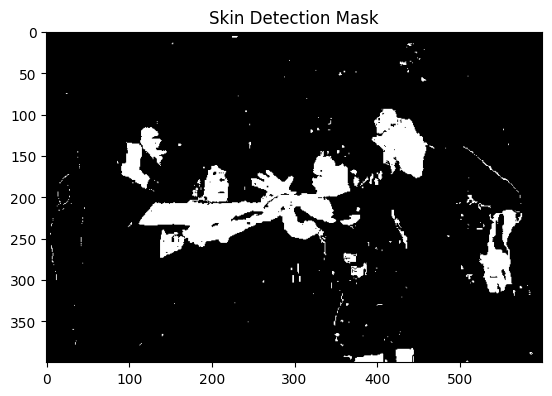

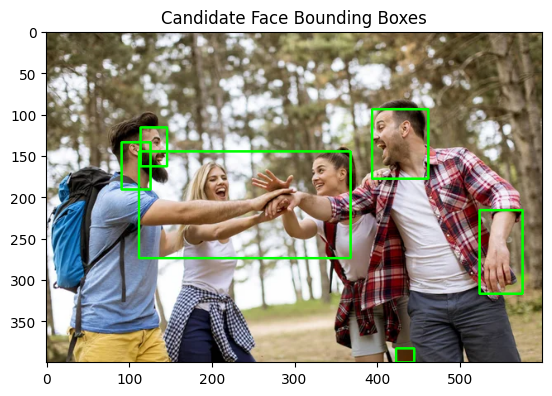

In [ ]:

plt.imshow(skin_mask, cmap='gray')
plt.title('Skin Detection Mask')
plt.show()

contours, _ = cv2.findContours(skin_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_with_boxes = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)
for cnt in contours:
    if cv2.contourArea(cnt) > 250:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Candidate Face Bounding Boxes')
plt.show()

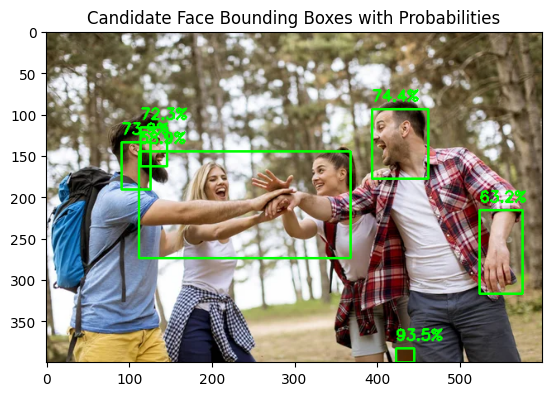

In [ ]:
# Compute per-pixel probability of skin

prob_skin = lik_skin / (lik_skin + lik_non + 1e-10)
prob_skin = prob_skin.reshape(img_skin.shape[:2])

img_with_boxes = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)
for cnt in contours:
    if cv2.contourArea(cnt) > 250:
        x, y, w, h = cv2.boundingRect(cnt)

        region_prob = prob_skin[y:y+h, x:x+w]
        avg_prob = region_prob.mean()

        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

        cv2.putText(
            img_with_boxes,
            f"{avg_prob*100:.1f}%",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Candidate Face Bounding Boxes with Probabilities')
plt.show()

Convergence at the iteration27


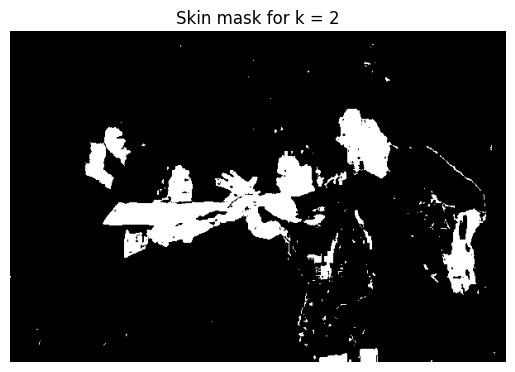

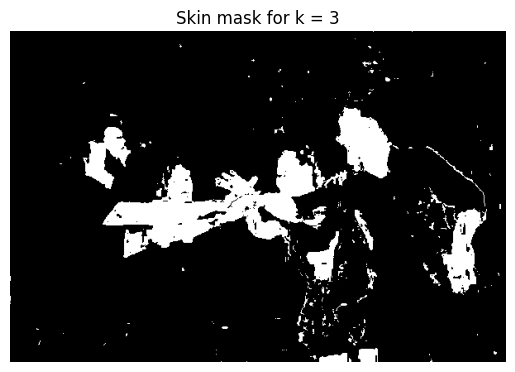

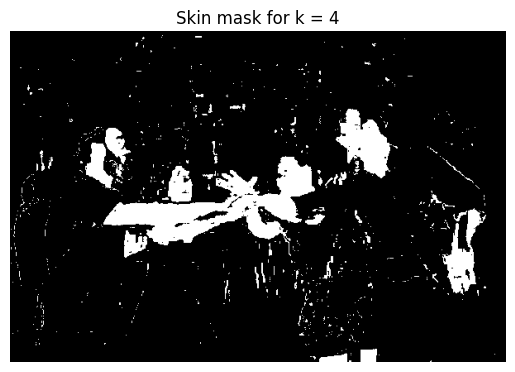

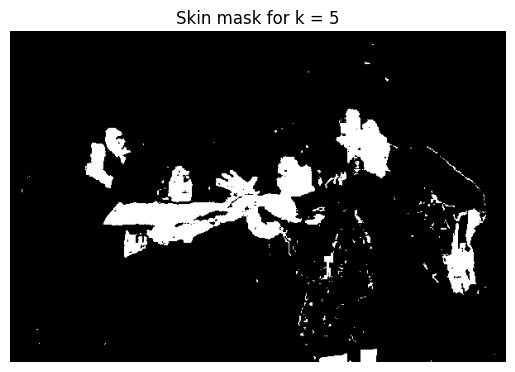

In [ ]:

threshold =  5
H, W = img_skin.shape[:2]

for k in [2,3,4,5]:
    weights_skin, means_skin, covs_skin = gmm_em(skin_cbcr, k)
    weights_non, means_non, covs_non = gmm_em(non_skin_cbcr, k)

    lik_skin = gmm_likelihood(test_cbcr, weights_skin, means_skin, covs_skin)
    lik_non = gmm_likelihood(test_cbcr, weights_non, means_non, covs_non)

    ratio = lik_skin / (lik_non + 1e-10)
    skin_mask_pred = (ratio > threshold).reshape(H, W)



    plt.figure()
    plt.title(f"Skin mask for k = {k}")
    plt.imshow(skin_mask_pred, cmap='gray')
    plt.axis('off')
    plt.show()





In [ ]:


def gmm_em(X, k, tol=1e-4, max_iter=100):
    n, d = X.shape
    np.random.seed(0)
    indices = np.random.choice(n, k, replace=False)
    means = X[indices]
    weights = np.ones(k) / k
    covs = [np.cov(X, rowvar=False) for _ in range(k)]

    prev_log_likelihood = None

    for iteration in range(max_iter):
        # E-step
        responsibilities = np.zeros((n, k))
        for i in range(k):
            responsibilities[:, i] = weights[i] * gaussian_pdf(X, means[i], covs[i])
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n
        means = (responsibilities.T @ X) / Nk[:, np.newaxis]
        covs = []
        for i in range(k):
            diff = X - means[i]
            cov = (responsibilities[:, i][:, np.newaxis] * diff).T @ diff / Nk[i]
            cov += np.eye(d) * 1e-6
            covs.append(cov)

        # Log-likelihood
        log_likelihood = np.sum(np.log(np.sum([
            weights[i] * gaussian_pdf(X, means[i], covs[i]) for i in range(k)
        ], axis=0)))

        if prev_log_likelihood is not None and abs(log_likelihood - prev_log_likelihood) < tol:
            break
        prev_log_likelihood = log_likelihood

    return weights, means, covs, iteration + 1
tols = [1e-3, 1e-4, 1e-5, 1e-6]
max_iters = [50,100]
print("Exploring the effects of tolerene and max_iter on GMM fittings:\n")
for max_iter in max_iters:
    print(f"=== Max Iteration: {max_iter} ===")
    for tol in tols:
        _, _, _, it_skin = gmm_em(skin_cbcr, 3, tol=tol, max_iter=100)
        _, _, _, it_non = gmm_em(non_skin_cbcr, 3, tol=tol, max_iter=100)
        print(f"Tolerance: {tol:<8} | Skin: {it_skin:3d} iters | Non-Skin: {it_non:3d} iters")
    print()


Exploring the effects of tolerene and max_iter on GMM fittings:

=== Max Iteration: 50 ===
Tolerance: 0.001    | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 0.0001   | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 1e-05    | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 1e-06    | Skin: 100 iters | Non-Skin: 100 iters

=== Max Iteration: 100 ===
Tolerance: 0.001    | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 0.0001   | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 1e-05    | Skin: 100 iters | Non-Skin: 100 iters
Tolerance: 1e-06    | Skin: 100 iters | Non-Skin: 100 iters



---